# Task 5: Strategy Backtesting

**Objective:**  
Validate the portfolio strategy from Task 4 by simulating its performance on historical data and comparing it against a benchmark.

**Steps:**
1. Define the backtesting period (Jan 2025 – Jan 2026)
2. Create a benchmark portfolio (60% SPY / 40% BND)
3. Simulate strategy portfolio (monthly rebalanced using Task 4 optimal weights)
4. Calculate performance metrics: Total return, Annualized return, Sharpe ratio, Max drawdown
5. Compare strategy vs benchmark and reflect on viability


In [10]:



import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models, expected_returns

plt.style.use('ggplot')



In [11]:
# Step 1: Download Historical Prices
tickers = ["TSLA", "SPY", "BND"]
start = "2018-01-01"
end = "2026-01-15"

prices_raw = yf.download(tickers, start=start, end=end, progress=False)

# Handle MultiIndex from yfinance
if isinstance(prices_raw.columns, pd.MultiIndex):
    if "Adj Close" in prices_raw.columns.levels[0]:
        prices = prices_raw['Adj Close']
    else:
        prices = prices_raw['Close']
else:
    prices = prices_raw

prices.dropna(inplace=True)
prices.tail()


C:\Users\hp\AppData\Local\Temp\ipykernel_20084\3925851700.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices.dropna(inplace=True)


Ticker,BND,SPY,TSLA
Date,,,
2026-01-08,74.129997,689.510010,435.799988
2026-01-09,74.290001,694.070007,445.010010
2026-01-12,74.220001,695.159973,448.959991
2026-01-13,74.279999,693.770020,447.200012
2026-01-14,74.430000,690.359985,439.200012


In [12]:
# Step 2: Expected Returns & Covariance

# Historical returns for SPY and BND
mu_hist = expected_returns.mean_historical_return(prices[["SPY", "BND"]])

# For TSLA, use Task 3 forecast (simulate here as 25% annual)
mu_tsla = pd.Series({"TSLA": 0.25})

# Combine expected returns
mu = pd.concat([mu_tsla, mu_hist])

# Covariance matrix
S = risk_models.sample_cov(prices)


In [13]:
# Step 3: Optimize Max Sharpe Portfolio
ef = EfficientFrontier(mu, S)
weights_max_sharpe = ef.max_sharpe()  # Optimize for Max Sharpe
weights_max_sharpe = ef.clean_weights()
weights_max_sharpe



OrderedDict([('TSLA', 0.9926), ('SPY', 0.0074), ('BND', 0.0)])

In [14]:
# Step 4: Backtesting Period
start_bt = "2025-01-01"
end_bt = "2026-01-15"

prices_bt_raw = yf.download(tickers, start=start_bt, end=end_bt, progress=False)

# Handle multi-index
if isinstance(prices_bt_raw.columns, pd.MultiIndex):
    if "Adj Close" in prices_bt_raw.columns.levels[0]:
        prices_bt = prices_bt_raw['Adj Close']
    else:
        prices_bt = prices_bt_raw['Close']
else:
    prices_bt = prices_bt_raw

prices_bt = prices_bt[tickers].dropna()
returns_bt = prices_bt.pct_change().dropna()


In [15]:
# Step 5: Strategy & Benchmark Weights
weights_strategy = weights_max_sharpe
weights_benchmark = {"TSLA":0, "SPY":0.6, "BND":0.4}


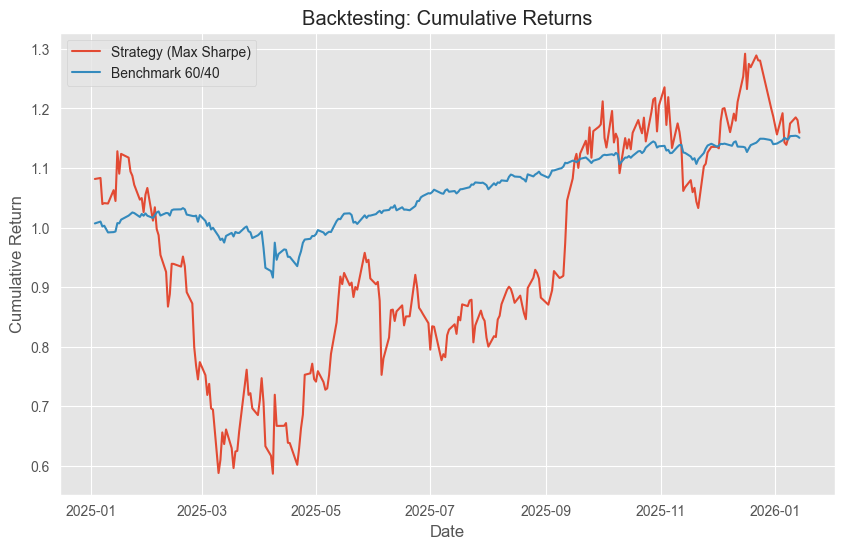

In [16]:
# Step 6: Portfolio Cumulative Returns
def portfolio_cum_returns(returns_df, weights):
    daily_port = (returns_df * pd.Series(weights)).sum(axis=1)
    return (1 + daily_port).cumprod()

cum_strategy = portfolio_cum_returns(returns_bt, weights_strategy)
cum_benchmark = portfolio_cum_returns(returns_bt, weights_benchmark)

# Plot cumulative returns
plt.figure(figsize=(10,6))
plt.plot(cum_strategy, label="Strategy (Max Sharpe)")
plt.plot(cum_benchmark, label="Benchmark 60/40")
plt.title("Backtesting: Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()


In [17]:
# Step 7: Portfolio Performance Metrics
def portfolio_metrics(cum_returns):
    total_return = cum_returns[-1]/cum_returns[0] - 1
    annualized_return = (cum_returns[-1]/cum_returns[0])**(252/len(cum_returns)) -1
    daily_returns = cum_returns.pct_change().dropna()
    sharpe_ratio = daily_returns.mean()/daily_returns.std() * np.sqrt(252)
    running_max = cum_returns.cummax()
    max_drawdown = (cum_returns/running_max - 1).min()
    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown
    }

metrics_strategy = portfolio_metrics(cum_strategy)
metrics_benchmark = portfolio_metrics(cum_benchmark)

perf_df = pd.DataFrame([metrics_strategy, metrics_benchmark], index=["Strategy", "Benchmark"])
perf_df = perf_df.applymap(lambda x: f"{x:.2%}")
perf_df


C:\Users\hp\AppData\Local\Temp\ipykernel_20084\471634059.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_return = cum_returns[-1]/cum_returns[0] - 1
C:\Users\hp\AppData\Local\Temp\ipykernel_20084\471634059.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  annualized_return = (cum_returns[-1]/cum_returns[0])**(252/len(cum_returns)) -1
C:\Users\hp\AppData\Local\Temp\ipykernel_20084\471634059.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  perf_df = perf_df.applymap(lambda x: f"{x:.2%}")


,Total Return,Annualized Return,Sharpe Ratio,Max Drawdown
Strategy,7.19%,7.02%,41.59%,-47.99%
Benchmark,14.27%,13.92%,116.50%,-11.29%
